In [1]:
# Step 1: Load environment variables (.env)
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Step 2: Import core components (StateGraph, LLM, Messages, MemorySaver)
from langgraph.graph import StateGraph ,START,END
from pydantic import BaseModel,Field
from typing import Literal,TypedDict,Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.checkpoint.memory import MemorySaver
# import operator

In [3]:
# Step 3: Initialize Groq LLM model
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7
)

In [4]:
# Step 4: Define ChatState schema with add_messages reducer (appends messages)
from  langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [5]:
# Step 5: Define node function to send conversation history to LLM
def Chat_node(state:ChatState):
    messages=state['messages']
    response=llm.invoke(messages)
    return {"messages":[response]}

In [6]:
# Step 6: Initialize memory checkpointer & StateGraph
check_pointer=MemorySaver()
graph=StateGraph(ChatState)

In [7]:
# Step 7: Add Chat node to graph
graph.add_node("Chat_node",Chat_node)

In [8]:
# Step 8: Connect graph flow (START -> Chat_node -> END)
graph.add_edge(START,"Chat_node")
graph.add_edge("Chat_node",END)

In [9]:
# Step 9: Compile graph with MemorySaver checkpointer for thread memory
workflow=graph.compile(checkpointer=check_pointer)

In [ ]:
# Step 10: Display visual workflow diagram
workflow

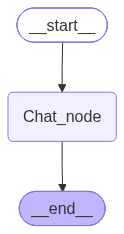

In [ ]:
# Step 11: Define initial test message input
initial_state={
    "messages":[HumanMessage(content="What is agentic ai in langgchain")]
}

In [ ]:
# Synchronous invocation example
# workflow.invoke(initial_state)["messages"][-1].content

In [ ]:
# Step 12: Stream LLM response in real-time with thread memory
for message_chunk,metadata in workflow.stream(initial_state,config={"configurable":{"thread_id":"thread_1"}},stream_mode="messages"):
    if message_chunk.content:
        print(message_chunk.content,end="",flush=True)

In the context of blockchain and artificial intelligence (AI), agentic AI refers to a type of AI that is capable of autonomous decision-making and self-directed behavior within a blockchain network.

Agentic AI is a key component of the concept of "autonomous agents" in blockchain, which enables AI systems to interact with other actors in the network, make decisions, and take actions on their own without being explicitly programmed to do so. This type of AI is designed to be self-aware, self-directed, and able to adapt to changing circumstances within the network.

In a blockchain context, agentic AI can be used in various ways, such as:

1. **Decentralized autonomous organizations (DAOs)**: Agentic AI can be used to create self-governing DAOs that can make decisions, manage assets, and take actions without the need for human intervention.
2. **Smart contracts**: Agentic AI can be integrated into smart contracts to enable them to make decisions and take actions based on changing circum

In [ ]:
# Step 13: Interactive chat loop (maintains memory using thread_id='1')
thread_id = "1"

while True:

    user_message = input("Type Here: ")
    print("User:", user_message)

    if user_message.lower().strip() in ["exit", "quit", "bye"]:
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    print("AI: ", end="", flush=True)

    for message_chunk, metadata in workflow.stream(
        {"messages": [HumanMessage(content=user_message)]},
        config=config,
        stream_mode="messages"
    ):
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)

    print()

In [ ]:
# Step 14: Inspect current conversation state saved in memory
workflow.get_state(config=config)

User: hii
AI: You're in a friendly mood today. Want to play a game, have a fun conversation, or is there something specific you'd like to talk about?
User: what is agentic ai
AI: Agentic AI refers to artificial intelligence systems that are designed to act independently, make decisions, and take actions on their own, similar to how humans exhibit agency. These AI systems have the ability to set goals, prioritize tasks, and adapt to changing situations, often using a combination of machine learning and cognitive architectures.

Agentic AI systems can be thought of as having several key characteristics:

1. **Autonomy**: The ability to make decisions and take actions without direct human supervision.
2. **Goals**: The ability to set and pursue goals, which can be determined by the AI system itself or by humans.
3. **Self-awareness**: The ability to have a sense of its own existence, capabilities, and limitations.
4. **Intentionality**: The ability to have intentions and goals that are no

In [ ]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='88ce9bd3-1fb1-4150-800a-565f74566236'), AIMessage(content='Is there something I can help you with?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--01a005ca-e1e0-70c2-ae9d-8969505b4664', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 10, 'total_tokens': 45}), HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='1fd78d8c-fcd4-42bc-b853-a621e49a375b'), AIMessage(content='Hi, how are you doing today?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--01a005ca-ec28-7c82-869e-b3daad6a2c63', tool_cal